# MLflow GenAI Evaluation – Results Visualisation

This notebook runs the evaluation subcommands from `scripts/mlflow/vanilla.py`
and visualises the results inline.

## Prerequisites

1. Start the MLflow tracking server in a separate terminal:
   ```bash
   make mlflow
   ```
2. The `mlflow>=3.12.0` dependency is already declared in `pyproject.toml`.

## References

- [MLflow GenAI Evaluation docs](https://mlflow.org/docs/latest/genai/)
- [Tutorial Step 5](../docs/tutorial/05-mlflow-genai-evaluation.md)


In [1]:
# Cell 1 – verify CLI help
!uv run python ../../scripts/mlflow/vanilla.py --help

                                                                                
 Usage: vanilla.py [OPTIONS] COMMAND [ARGS]...                                  
                                                                                
 MLflow GenAI Evaluation CLI                                                    
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --verbose  -v        Enable verbose (DEBUG) logging                          │
│ --help               Show this message and exit.                             │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─ Commands ───────────────────────────────────────────────────────────────────╮
│ trace          Run the QA function and record traces in MLflow.              │
│ dataset        Print the inline evaluation dataset as JSON.                  │
│ evaluate       Run heurist

## 1. Configure MLflow

Point the client at the local tracking server started by `make mlflow`.
Adjust `MLFLOW_TRACKING_URI` if you are using a different port or host.

In [2]:
import os
import sys

# Make the repository root importable so concierge.settings is available.
REPO_ROOT = os.path.abspath("../..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import mlflow  # noqa: E402

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
EXPERIMENT_NAME = os.getenv("MLFLOW_EXPERIMENT_NAME", "microsoft-foundry-vanilla")

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI : {TRACKING_URI}")
print(f"Experiment   : {EXPERIMENT_NAME}")
print(f"MLflow version: {mlflow.__version__}")

/Users/ks6088ts/src/github.com/ks6088ts-labs/concierge/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tracking URI : http://127.0.0.1:5000
Experiment   : microsoft-foundry-vanilla
MLflow version: 3.13.0


## 2. Inline evaluation dataset

Define the same five QA pairs used by `scripts/mlflow/vanilla.py`.

In [3]:
from typing import Any

import pandas as pd

# Ground truth lives under the MLflow-recognized ``expectations`` key so that
# scorers can receive it via the ``expectations`` parameter.
DATASET: list[dict[str, Any]] = [
    {
        "inputs": {"question": "What is the capital of France?"},
        "expectations": {"expected_response": "Paris"},
    },
    {
        "inputs": {"question": "What is 2 + 2?"},
        "expectations": {"expected_response": "4"},
    },
    {
        "inputs": {"question": "Who wrote Romeo and Juliet?"},
        "expectations": {"expected_response": "William Shakespeare"},
    },
    {
        "inputs": {"question": "What is the boiling point of water in Celsius?"},
        "expectations": {"expected_response": "100"},
    },
    {
        "inputs": {"question": "What planet is closest to the Sun?"},
        "expectations": {"expected_response": "Mercury"},
    },
]

df_dataset = pd.DataFrame(
    [
        {
            "question": row["inputs"]["question"],
            "expected_response": row["expectations"]["expected_response"],
        }
        for row in DATASET
    ]
)
df_dataset

,question,expected_response
0,What is the capital of France?,Paris
1,What is 2 + 2?,4
2,Who wrote Romeo and Juliet?,William Shakespeare
3,What is the boiling point of water in Celsius?,100
4,What planet is closest to the Sun?,Mercury


## 3. Target application: simple QA function

The same deterministic QA function used in `scripts/mlflow/vanilla.py`.

In [4]:
def simple_qa(question: str) -> str:
    """Return hard-coded answers for the built-in dataset."""
    answers = {
        "what is the capital of france?": "Paris",
        "what is 2 + 2?": "4",
        "who wrote romeo and juliet?": "William Shakespeare",
        "what is the boiling point of water in celsius?": "100 degrees Celsius",
        "what planet is closest to the sun?": "Mercury",
    }
    return answers.get(question.lower().strip(), "I don't know.")


# Quick smoke test
for row in DATASET:
    q = row["inputs"]["question"]
    print(f"Q: {q}")
    print(f"A: {simple_qa(q)}\n")

Q: What is the capital of France?
A: Paris

Q: What is 2 + 2?
A: 4

Q: Who wrote Romeo and Juliet?
A: William Shakespeare

Q: What is the boiling point of water in Celsius?
A: 100 degrees Celsius

Q: What planet is closest to the Sun?
A: Mercury



## 4. Heuristic evaluation (no Azure required)

Define three pure-Python scorers and run `mlflow.genai.evaluate()`.

In [5]:
from mlflow.genai.scorers import scorer


@scorer
def exact_match(outputs: str, expectations: dict[str, Any]) -> float:
    """1.0 when output == expected_response (case-insensitive)."""
    expected_response = expectations["expected_response"]
    return 1.0 if outputs.strip().lower() == expected_response.strip().lower() else 0.0


@scorer
def contains(outputs: str, expectations: dict[str, Any]) -> float:
    """1.0 when output contains expected_response."""
    expected_response = expectations["expected_response"]
    return 1.0 if expected_response.strip().lower() in outputs.strip().lower() else 0.0


@scorer
def non_empty(outputs: str) -> float:
    """1.0 when output is non-empty."""
    return 1.0 if outputs.strip() else 0.0


# MLflow unpacks each row's ``inputs`` dict as keyword arguments, so ``simple_qa``
# (which takes ``question``) can be used directly as the prediction function.
with mlflow.start_run(run_name="notebook-heuristic-eval"):
    heuristic_results = mlflow.genai.evaluate(
        data=DATASET,
        predict_fn=simple_qa,
        scorers=[exact_match, contains, non_empty],
    )

print(heuristic_results.metrics)

2026/06/14 06:43:51 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.
Evaluating: 100%|█| 5/5 [Elapsed: 00:01, Remaining: 00:00] [predict_fn: 11%, scorers: 89%]


{'contains/mean': np.float64(1.0), 'non_empty/mean': np.float64(1.0), 'exact_match/mean': np.float64(0.8)}


### 4.1 Per-row heuristic results

In [6]:
df_heuristic = heuristic_results.tables["eval_results"]
df_heuristic

,trace_id,contains/value,non_empty/value,exact_match/value,expected_response/value,trace,client_request_id,state,request_time,execution_duration,request,response,trace_metadata,tags,spans,assessments
0,tr-bc2b3c3b54cfe82c5e6daf453ad94423,1.0,1.0,1.0,Paris,"{""info"": {""trace_id"": ""tr-bc2b3c3b54cfe82c5e6d...",None,OK,1781387032475,0,{'question': 'What is the capital of France?'},Paris,"{'mlflow.source.type': 'NOTEBOOK', 'mlflow.tra...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'vCs8O1TP6Cxeba9FOtlEIw==', 'spa...",[{'assessment_id': 'a-c0eafc319df24ae895d8f149...
1,tr-9a2725677b80da66b22fbb5c1529aa83,1.0,1.0,1.0,4,"{""info"": {""trace_id"": ""tr-9a2725677b80da66b22f...",None,OK,1781387032475,0,{'question': 'What is 2 + 2?'},4,"{'mlflow.source.type': 'NOTEBOOK', 'mlflow.tra...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'miclZ3uA2mayL7tcFSmqgw==', 'spa...",[{'assessment_id': 'a-aacdd33a1743458cbb5ebcf6...
2,tr-b294d23a96988267cc55165edec97009,1.0,1.0,1.0,William Shakespeare,"{""info"": {""trace_id"": ""tr-b294d23a96988267cc55...",None,OK,1781387032475,0,{'question': 'Who wrote Romeo and Juliet?'},William Shakespeare,"{'mlflow.user': 'ks6088ts', 'mlflow.traceOutpu...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'spTSOpaYgmfMVRZe3slwCQ==', 'spa...",[{'assessment_id': 'a-2c05aced26b840c0aaf76fd5...
3,tr-17cca3474c3b6cdd2b338e7ea80732ed,1.0,1.0,0.0,100,"{""info"": {""trace_id"": ""tr-17cca3474c3b6cdd2b33...",None,OK,1781387032476,0,{'question': 'What is the boiling point of wat...,100 degrees Celsius,"{'mlflow.source.type': 'NOTEBOOK', 'mlflow.tra...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'F8yjR0w7bN0rM45+qAcy7Q==', 'spa...",[{'assessment_id': 'a-407cd87c3e2a4278b07f7664...
4,tr-36c9c666a2d27c56be0ef102e8a5e959,1.0,1.0,1.0,Mercury,"{""info"": {""trace_id"": ""tr-36c9c666a2d27c56be0e...",None,OK,1781387032476,0,{'question': 'What planet is closest to the Su...,Mercury,"{'mlflow.user': 'ks6088ts', 'mlflow.trace_sche...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'NsnGZqLSfFa+DvEC6KXpWQ==', 'spa...",[{'assessment_id': 'a-a227620c9c1c4f18ada83b62...


### 4.2 Visualise heuristic scores

In [7]:
import matplotlib.pyplot as plt

score_cols = [c for c in df_heuristic.columns if c in ("exact_match", "contains", "non_empty")]
if score_cols and "inputs/question" in df_heuristic.columns:
    ax = df_heuristic.set_index("inputs/question")[score_cols].plot(
        kind="bar",
        figsize=(10, 4),
        title="Heuristic Scorer Results",
        ylim=(0, 1.1),
        rot=30,
    )
    ax.set_ylabel("Score")
    plt.tight_layout()
    plt.show()
else:
    print("Score columns not found – check column names above.")
    print(df_heuristic.columns.tolist())

Matplotlib is building the font cache; this may take a moment.


Score columns not found – check column names above.
['trace_id', 'contains/value', 'non_empty/value', 'exact_match/value', 'expected_response/value', 'trace', 'client_request_id', 'state', 'request_time', 'execution_duration', 'request', 'response', 'trace_metadata', 'tags', 'spans', 'assessments']


## 5. Custom scorer: token overlap

In [8]:
@scorer
def token_overlap(outputs: str, expectations: dict[str, Any]) -> float:
    """Jaccard similarity between output and expected_response token sets."""
    expected_response = expectations["expected_response"]
    a = set(outputs.lower().split())
    b = set(expected_response.lower().split())
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)


with mlflow.start_run(run_name="notebook-custom-scorer-eval"):
    custom_results = mlflow.genai.evaluate(
        data=DATASET,
        predict_fn=simple_qa,
        scorers=[token_overlap],
    )

print(custom_results.metrics)

2026/06/14 06:44:06 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.
Evaluating: 100%|█| 5/5 [Elapsed: 00:00, Remaining: 00:00] [predict_fn: 72%, scorers: 28%]


{'token_overlap/mean': np.float64(0.8666666666666668)}


### 5.1 Per-row custom scorer results

In [9]:
df_custom = custom_results.tables["eval_results"]
df_custom

,trace_id,token_overlap/value,expected_response/value,trace,client_request_id,state,request_time,execution_duration,request,response,trace_metadata,tags,spans,assessments
0,tr-c89e3ac0c13cb271c4bf6bce50f8fc15,1.000000,Paris,"{""info"": {""trace_id"": ""tr-c89e3ac0c13cb271c4bf...",None,OK,1781387046147,0,{'question': 'What is the capital of France?'},Paris,"{'mlflow.user': 'ks6088ts', 'mlflow.traceOutpu...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'yJ46wME8snHEv2vOUPj8FQ==', 'spa...",[{'assessment_id': 'a-b88615bf2be24757b8baea6f...
1,tr-d0971c03516169915487e98fc441e584,1.000000,4,"{""info"": {""trace_id"": ""tr-d0971c03516169915487...",None,OK,1781387046147,0,{'question': 'What is 2 + 2?'},4,"{'mlflow.source.type': 'NOTEBOOK', 'mlflow.tra...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': '0JccA1FhaZFUh+mPxEHlhA==', 'spa...",[{'assessment_id': 'a-6a36483620454cb29a2ce3eb...
2,tr-220389f334cfaf4d43b4f44974dfbfee,1.000000,William Shakespeare,"{""info"": {""trace_id"": ""tr-220389f334cfaf4d43b4...",None,OK,1781387046148,0,{'question': 'Who wrote Romeo and Juliet?'},William Shakespeare,"{'mlflow.source.type': 'NOTEBOOK', 'mlflow.tra...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'IgOJ8zTPr01DtPRJdN+/7g==', 'spa...",[{'assessment_id': 'a-501ff8826dcc4ffa9623ddc8...
3,tr-2311234666d9121497c2c256c6873e3c,0.333333,100,"{""info"": {""trace_id"": ""tr-2311234666d9121497c2...",None,OK,1781387046148,0,{'question': 'What is the boiling point of wat...,100 degrees Celsius,"{'mlflow.user': 'ks6088ts', 'mlflow.trace_sche...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'IxEjRmbZEhSXwsJWxoc+PA==', 'spa...",[{'assessment_id': 'a-2c254b3c578840128faecff8...
4,tr-b30889628af5e63c2c9fcc752879eba2,1.000000,Mercury,"{""info"": {""trace_id"": ""tr-b30889628af5e63c2c9f...",None,OK,1781387046148,0,{'question': 'What planet is closest to the Su...,Mercury,"{'mlflow.user': 'ks6088ts', 'mlflow.trace_sche...",{'mlflow.trace.spansLocation': 'TRACKING_STORE...,"[{'trace_id': 'swiJYor15jwsn8x1KHnrog==', 'spa...",[{'assessment_id': 'a-b3451eae4bf74f10997f73b6...


## 6. Compare evaluation runs

Search all runs in the current experiment and display a side-by-side metrics table.

In [10]:
from typing import cast

runs = cast(
    pd.DataFrame,
    mlflow.search_runs(
        experiment_names=[EXPERIMENT_NAME],
        max_results=20,
        output_format="pandas",
    ),
)

keep_cols = [
    c for c in runs.columns if c.startswith("metrics.") or c in {"run_id", "tags.mlflow.runName", "start_time"}
]
df_compare = runs[keep_cols].rename(columns={"tags.mlflow.runName": "run_name"})
df_compare = df_compare.sort_values("start_time", ascending=False) if "start_time" in df_compare.columns else df_compare
df_compare

,run_id,start_time,metrics.token_overlap/mean,metrics.exact_match/mean,metrics.non_empty/mean,metrics.contains/mean,run_name
0,13390a182e02465c8794c99614d19545,2026-06-13 21:44:06.096000+00:00,0.866667,NaN,NaN,NaN,notebook-custom-scorer-eval
1,b6ab04dc6f0f4b9d88103ffdd7066686,2026-06-13 21:43:51.687000+00:00,NaN,0.8,1.0,1.0,notebook-heuristic-eval


### 6.1 Aggregate metrics bar chart

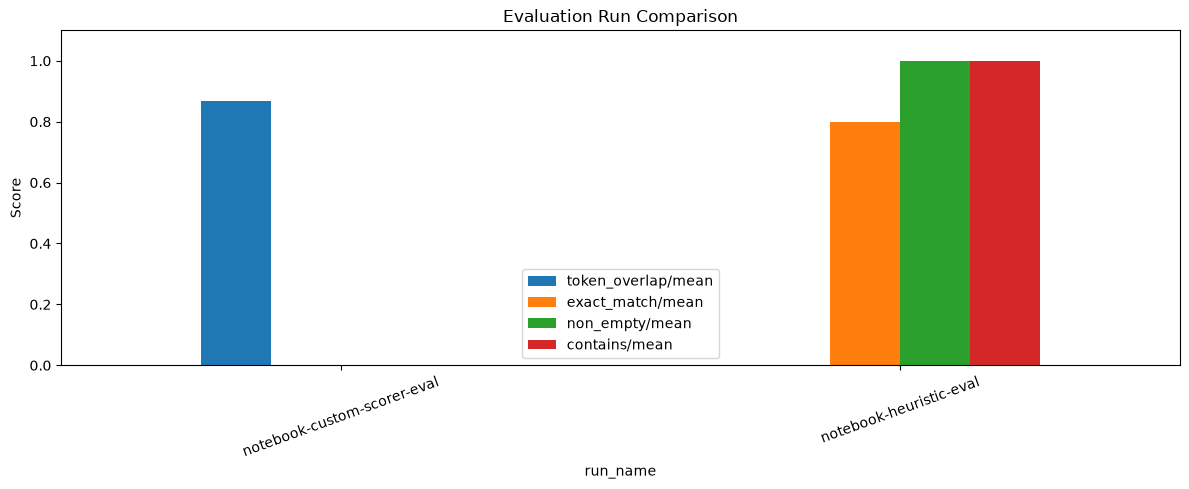

In [11]:
metric_cols = [c for c in df_compare.columns if c.startswith("metrics.")]
if metric_cols and "run_name" in df_compare.columns:
    plot_df = df_compare.set_index("run_name")[metric_cols]
    plot_df.columns = [c.replace("metrics.", "") for c in plot_df.columns]
    ax = plot_df.plot(
        kind="bar",
        figsize=(12, 5),
        title="Evaluation Run Comparison",
        ylim=(0, 1.1),
        rot=20,
    )
    ax.set_ylabel("Score")
    plt.tight_layout()
    plt.show()
else:
    print("No metric columns found or no run_name column. Run evaluate / custom-scorer first.")

## 7. Open MLflow UI

All runs are also visible in the interactive MLflow UI:

```
http://127.0.0.1:5000
```

Navigate to **Experiments → [experiment name] → Evaluation** for
colour-coded comparisons, trace drill-downs, and run diffs.